# **Simulación Numérica de la Ecuación de Calor 2D con Condiciones Mixtas.**
Este notebook aborda la resolución numérica del siguiente problema de difusión de temperatura en dos dimensiones:

$$
T_{tt} - 0.01(T_{xx} - T_{yy}) = 0, \quad T = T(x,y,t), \quad 0 < x < 1, \quad 0 < y < 1, \quad t > 0
$$

**Condiciones de Frontera (CF):**
- $ \frac{\partial T}{\partial x}(0, y, t) = 0 $  (Neumann en $x=0$)
- $ \frac{\partial T}{\partial y}(1, y, t) = 0 $  (Neumann en $y=1$)
- $ T(x, 0, t) = 20 $  (Dirichlet en $y=0$)
- $ T(x, 1, t) = 50 $  (Dirichlet en $y=1$)

**Condición Inicial (CI):**
$$
T(x, y, 0) = -50 \cos\left(\frac{\pi}{2}x\right) \cos\left(\frac{\pi}{2}y\right)
$$

**Objetivo:**
- Resolver la evolución temporal (**solución transitoria**) utilizando métodos explícitos e implícitos, incluyendo análisis de convergencia espacial y temporal.
- Calcular la **solución estacionaria** mediante métodos iterativos e implícitos, con y sin matrices dispersas (**sparse**).
- Presentar los resultados a través de representaciones gráficas de la distribución de temperatura y del análisis de estabilidad y precisión de los métodos empleados.

El trabajo incluirá además una comparación de mallados, análisis de la estabilidad numérica en función de $ \lambda $ y un enfoque en la optimización computacional usando matrices sparse.

## **Introducción.**
**Definición del problema.** En este trabajo se resuelve numéricamente el siguiente problema de difusión de temperatura en dos dimensiones:
$$
T_{tt} - 0.01(T_{xx} - T_{yy}) = 0, \quad T = T(x, y, t), \quad 0 < x < 1, \quad 0 < y < 1, \quad t > 0
$$

dónde $T$ representa la temperatura, $x$ y $y$ son las coordenadas espaciales y $t$ es el tiempo.

**Condiciones iniciales y de frontera.**
- **Condición Inicial (CI):**
$$
T(x, y, 0) = -50 \cos\left( \frac{\pi}{2} x \right) \cos\left( \frac{\pi}{2} y \right)
$$
- **Condiciones de Frontera (CF):**
    - $\frac{\partial T}{\partial x}(0, y, t) = 0$  (Neumann en $x=0$)
    - $\frac{\partial T}{\partial y}(1, y, t) = 0$  (Neumann en $y=1$)
    - $T(x, 0, t) = 20$  (Dirichlet en $y=0$)
    - $T(x, 1, t) = 50$  (Dirichlet en $y=1$)

**Parámetros físicos y de simulación.** Se trabajará sobre una región cuadrada $(x,y) \in (0,1) \times (0,1)$ durante un intervalo de tiempo $t > 0$. El coeficiente de difusión efectivo es $0.01$.

## **Configuración Inicial.**
En este apartado se procederá a la importación de las librerías necesarias para la ejecución del taller, las cuales han sido previamente definidas en el archivo **`requirements.txt`**. Esto garantiza la compatibilidad del entorno de trabajo y permite realizar de manera eficiente el procesamiento de datos, el cálculo de métricas estadísticas y la visualización de resultados, asegurando así una correcta ejecución de los ejercicios posteriores.

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
import pandas as pd


pd.set_option('display.max_colwidth', None)

In [36]:
# Parámetros físicos
alpha = 0.01        # Coeficiente de difusión.

# Dimensiones del dominio
Lx = 1.0            # Longitud en x.
Ly = 1.0            # Longitud en y.

# Discretización espacial
Nx = 20             # Número de nodos en x.
Ny = 20             # Número de nodos en y.
dx = Lx / (Nx - 1)  # Paso en x.
dy = Ly / (Ny - 1)  # Paso en y.

# Discretización temporal.
dt = 0.0005         # Paso temporal.
T_max = 0.1         # Tiempo máximo de simulación.
Nt = int(T_max / dt)  # Número de pasos de tiempo.

# Parámetro de estabilidad (solo relevante para método explícito).
lambda_x = alpha * dt / (dx**2)
lambda_y = alpha * dt / (dy**2)

print(f"lambda_x = {lambda_x:.5f}, lambda_y = {lambda_y:.5f}")

lambda_x = 0.00181, lambda_y = 0.00181


In [37]:
# Malla espacial
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)

## **Solución Transitoria.**
En esta sección se resuelve la evolución temporal de la temperatura, es decir, cómo cambia $ T(x, y, t) $ con el tiempo.

Se utilizarán distintos métodos numéricos para aproximar la solución:
- Método explícito.
- Método implícito.
- Método implícito usando matrices sparse.

En cada método se implementará la discretización temporal y espacial, se simulará la evolución durante un intervalo de tiempo dado y se representarán los resultados.

Además, se realizará un análisis de convergencia para comprobar la estabilidad y precisión de los métodos según el mallado espacial y los parámetros de tiempo.

El objetivo es obtener la distribución de temperaturas en varios instantes $t$ y observar su evolución hacia el estado estacionario.

### **Método Explícito.**

In [38]:
import numpy as np
import pandas as pd

# --- Configuración general ---
alpha = 0.00052
Lx = 1.0
Ly = 1.0
Nx = 20
Ny = 20
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

dt = 0.5
T_max = 300
Nt = int(T_max / dt)

lambda_x = alpha * dt / dx**2
lambda_y = alpha * dt / dy**2

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)

# --- Inicialización ---
T = np.zeros((Ny, Nx))
frames = []

i_c = Nx // 2
j_c = Ny // 2

# --- Simulación principal ---
for n in range(Nt):
    T_new = T.copy()
    for j in range(1, Ny - 1):
        for i in range(1, Nx - 1):
            fuente = 1.0 if (i == i_c and j == j_c and n * dt < 200) else 0.0
            T_new[j, i] = T[j, i] \
                + lambda_x * (T[j, i+1] - 2*T[j, i] + T[j, i-1]) \
                + lambda_y * (T[j+1, i] - 2*T[j, i] + T[j-1, i]) \
                + dt * fuente

    # Condiciones de frontera
    T_new[:, 0] = 0
    T_new[:, -1] = 0
    T_new[-1, :] = 0
    T_new[0, :] = T_new[1, :]  # Neumann en y = 0

    T = T_new.copy()

    if n % 20 == 0:
        frames.append(T.copy())

# --- Guardar resultados ---
np.save("frames_temp.npy", np.array(frames))  # Animación
np.save("X_mesh.npy", X)
np.save("Y_mesh.npy", Y)

df_temp = pd.DataFrame(T, columns=[f"x{i}" for i in range(Nx)])
df_temp.to_csv("resultado_temperatura_final.csv", index=False)


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- Cargar datos guardados ---
frames = np.load("frames_temp.npy")
X = np.load("X_mesh.npy")
Y = np.load("Y_mesh.npy")

dt = 0.5
intervalos = 20

# --- Calcular escala de color ---
temp_max = np.max(frames)

# --- Crear animación ---
fig, ax = plt.subplots()
cax = ax.imshow(frames[0], cmap='inferno', origin='lower', extent=[0, 1, 0, 1], vmin=0, vmax=temp_max)
fig.colorbar(cax)
ax.set_title('Distribución de Temperatura')

def animate(i):
    cax.set_array(frames[i])
    ax.set_title(f'Tiempo = {i*intervalos*dt:.1f} s')
    return cax,

ani = animation.FuncAnimation(fig, animate, frames=len(frames), interval=120, blit=False)
ani.save("proyecto_fuente_calor.gif", writer='pillow')
plt.close()


### **Análisis de Convergencia (Método Explícito).**

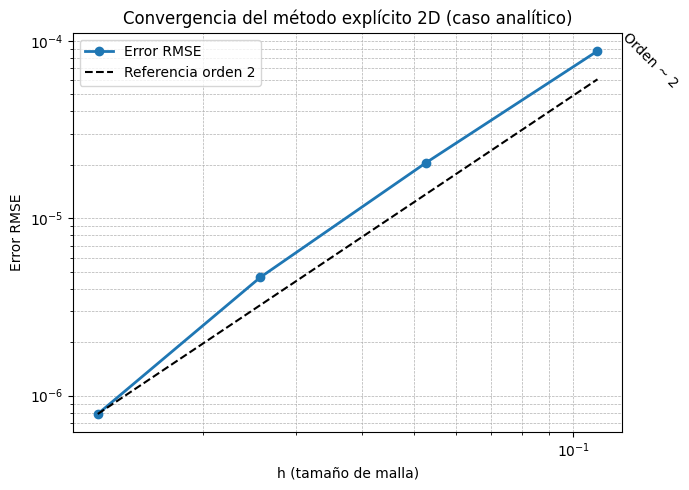

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Simulación explícita en 2D (caso con solución exacta)
# ---------------------------
def simulate_con_analitica(Nx, Ny, dt, T_max, alpha=0.01):
    dx = 1.0 / (Nx - 1)
    dy = 1.0 / (Ny - 1)
    lambda_x = alpha * dt / dx**2
    lambda_y = alpha * dt / dy**2
    Nt = int(T_max / dt)

    # Malla
    x = np.linspace(0, 1, Nx)
    y = np.linspace(0, 1, Ny)
    X, Y = np.meshgrid(x, y)

    # Condición inicial analítica
    T = np.sin(np.pi * X) * np.sin(np.pi * Y)

    for n in range(Nt):
        T_new = T.copy()
        for j in range(1, Ny - 1):
            for i in range(1, Nx - 1):
                T_new[j, i] = T[j, i] \
                    + lambda_x * (T[j, i+1] - 2*T[j, i] + T[j, i-1]) \
                    + lambda_y * (T[j+1, i] - 2*T[j, i] + T[j-1, i])
        # Condiciones de frontera Dirichlet homogéneas
        T_new[:, 0] = 0
        T_new[:, -1] = 0
        T_new[0, :] = 0
        T_new[-1, :] = 0
        T = T_new.copy()

    return T, X, Y, dx

# ---------------------------
# Solución analítica exacta
# ---------------------------
def solucion_analitica(X, Y, t, alpha):
    return np.sin(np.pi * X) * np.sin(np.pi * Y) * np.exp(-2 * (np.pi**2) * alpha * t)

# ---------------------------
# Configuración
# ---------------------------
alpha = 0.01
T_max = 0.1
dt = 0.0005

resolutions = [10, 20, 40, 80]
errores = []
h_vals = []

for N in resolutions:
    T_num, X, Y, h = simulate_con_analitica(N, N, dt, T_max, alpha)
    T_exacta = solucion_analitica(X, Y, T_max, alpha)
    error = np.sqrt(np.mean((T_num - T_exacta)**2))
    errores.append(error)
    h_vals.append(h)

# ---------------------------
# Graficar convergencia
# ---------------------------
h_vals = np.array(h_vals)
errores = np.array(errores)

# Ordenar por h
orden = np.argsort(h_vals)
h_vals = h_vals[orden]
errores = errores[orden]

# Línea de orden 2
h_ref = np.array([h_vals[0], h_vals[-1]])
error_ref = errores[0] * (h_ref / h_ref[0])**2

plt.figure(figsize=(7, 5))
plt.loglog(h_vals, errores, 'o-', label='Error RMSE', linewidth=2)
plt.loglog(h_ref, error_ref, 'k--', label='Referencia orden 2')

# Anotación
plt.text(h_ref[1]*1.1, error_ref[1]*0.9, 'Orden ~ 2', fontsize=10, rotation=-45)

plt.xlabel('h (tamaño de malla)')
plt.ylabel('Error RMSE')
plt.title('Convergencia del método explícito 2D (caso analítico)')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.tight_layout()
plt.show()


### **Método Implícito.**

## Método Implícito para la Solución Transitoria del Calor en 2D

Se utiliza el método \textbf{Backward Euler} (totalmente implícito) para resolver la ecuación:

$$
\frac{\partial T}{\partial t} = \alpha \left( \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \right)
$$

### Supuestos y configuración

- Dominio: $[0,1] \times [0,1]$
- Difusividad térmica: $\alpha = 1$
- Paso espacial: $h = \frac{L}{N+1}$ con $L = 1$
- Tiempo total de simulación: $T_{\text{total}} = 0.1$
- Paso de tiempo: $\Delta t = 0.001$

### Condiciones

- Condición inicial:
  $$
  T(x,y,0) = -50 \cos\left(\frac{\pi x}{2}\right)\cos\left(\frac{\pi y}{2}\right)
  $$
- Condiciones de frontera:
  - Laterales verticales (x = 0 y x = 1): aisladas $\Rightarrow \frac{\partial T}{\partial x} = 0$
  - Inferior y superior (y = 0 y y = 1): Dirichlet $\Rightarrow T = 20$ (abajo), $T = 50$ (arriba)

### Discretización del esquema implícito

La ecuación se reescribe como un sistema lineal en cada paso de tiempo:

$$
\left( I - \Delta t \cdot \alpha \cdot (D_x + D_y) \right) T^{n+1} = T^n
$$

donde $D_x$ y $D_y$ son operadores de derivada segunda discretizados con diferencias finitas.

---

### Visualización en movimiento

Para mostrar la evolución térmica del sistema, se generó una animación usando `matplotlib.animation.FuncAnimation`, la cual permite observar cómo cambia la distribución de temperatura en el dominio conforme avanza el tiempo.

Se presentan visualizaciones para tiempos entre $t = 0$ y $t = 0.1$ segundos, lo que permite interpretar claramente la dinámica de propagación del calor.


In [61]:
import numpy as np

# Parámetros físicos y numéricos
alpha = 1.0      # difusividad térmica
L = 1.0          # longitud del dominio
T_total = 0.1    # tiempo total de simulación
dt = 0.001       # paso de tiempo
N = 10           # número de puntos internos por eje

h = L / (N + 1)           # paso espacial
nt = int(T_total / dt)    # número de pasos de tiempo



In [62]:
from scipy.sparse import diags

def build_matrix_A(N, alpha, dt, h):
    # Matriz 1D de derivada segunda
    main = -2 * np.ones(N)
    off = np.ones(N - 1)
    D = diags([off, main, off], [-1, 0, 1]).toarray() / h**2
    
    I = np.eye(N)
    L2D = np.kron(I, D) + np.kron(D, I)  # Laplaciano 2D
    A = np.eye(N*N) - dt * alpha * L2D
    return A


In [63]:
def set_initial_condition(N, h):
    T0 = np.zeros((N, N))
    x = np.linspace(h, 1 - h, N)
    y = np.linspace(h, 1 - h, N)
    for i in range(N):
        for j in range(N):
            T0[i, j] = -50 * np.cos(np.pi * x[i] / 2) * np.cos(np.pi * y[j] / 2)
    return T0


In [64]:
def apply_boundary_conditions(T, N):
    # Condiciones Dirichlet en y = 0 y y = 1
    T[:, 0] = 20
    T[:, -1] = 50
    # Condiciones Neumann (aislantes) en x = 0 y x = 1
    T[0, :] = T[1, :]
    T[-1, :] = T[-2, :]
    return T


In [65]:
from scipy.linalg import solve

A = build_matrix_A(N, alpha, dt, h)
Tn = set_initial_condition(N, h)

snapshots = []
times = []

for n in range(1, nt + 1):
    Tn = apply_boundary_conditions(Tn, N)
    Tn_flat = Tn.flatten()
    Tnp1_flat = solve(A, Tn_flat)
    Tn = Tnp1_flat.reshape((N, N))

    # Guardar cada 10 pasos de tiempo para animación suave
    if n % 10 == 0:
        snapshots.append(Tn.copy())
        times.append(n * dt)



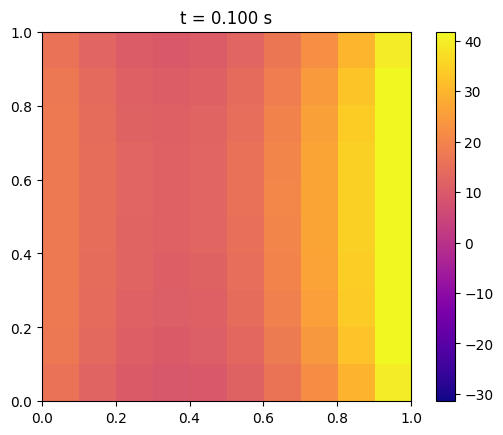

In [66]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Crear figura y eje
fig, ax = plt.subplots()
im = ax.imshow(snapshots[0], origin='lower', extent=[0,1,0,1], cmap='plasma',
               vmin=np.min(snapshots[0]), vmax=np.max(snapshots[0]))
cbar = plt.colorbar(im, ax=ax)
title = ax.set_title('')

# Función de actualización de cada frame
def update(frame):
    im.set_array(snapshots[frame])
    title.set_text(f"t = {times[frame]:.3f} s")
    return [im, title]

# Crear animación
ani = FuncAnimation(fig, update, frames=len(snapshots), interval=1000, blit=True)

# Guardar como GIF
ani.save("solucion_transitoria_implicita.gif", writer=PillowWriter(fps=1))



### **Método Implícito con Matrices Sparse.**

In [ ]:
from scipy.sparse import kron, eye, csr_matrix
from scipy.sparse.linalg import spsolve
import numpy as np

def metodo_implicito_sparse_2D(Nx, Ny, alpha, dx, dy, dt, Nt):
    Ix = eye(Nx)
    Iy = eye(Ny)
    Ax = csr_matrix(construir_matriz_A(Nx))
    Ay = csr_matrix(construir_matriz_A(Ny))

    lambda_x = alpha * dt / dx**2
    lambda_y = alpha * dt / dy**2

    M = eye(Nx * Ny) - lambda_x * kron(Iy, Ax) - lambda_y * kron(Ay, Ix)

    T = np.zeros((Nx, Ny))
    T[:, 0] = 20
    T[:, -1] = 50

    resultados = {}

    for n in range(Nt):
        b = T.flatten()
        T_next_flat = spsolve(M, b)
        T = T_next_flat.reshape((Nx, Ny))

        T[:, 0] = 20
        T[:, -1] = 50
        T[0, :] = T[1, :]
        T[-1, :] = T[-2, :]

        # Guardar 60 pasos para animación
        if n % max(1, Nt // 60) == 0:
            resultados[n] = T.copy()

    return resultados



✅ Animación guardada como 'animacion_sparse.gif'


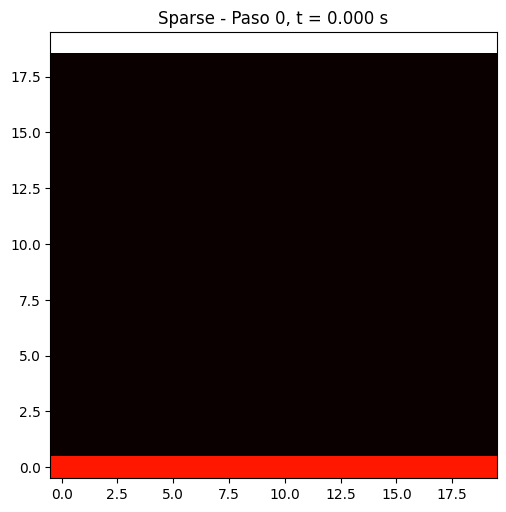

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import animation

# Ejecutar el método y generar resultados
resultados_sparse = metodo_implicito_sparse_2D(Nx, Ny, alpha, dx, dy, dt, Nt)
tiempos = sorted(resultados_sparse.keys())

# Crear animación con imshow
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(resultados_sparse[tiempos[0]].T, cmap='hot', origin='lower', vmin=0, vmax=50)
title = ax.set_title("")

def actualizar(frame):
    T = resultados_sparse[tiempos[frame]]
    im.set_data(T.T)
    title.set_text(f"Sparse - Paso {tiempos[frame]}, t = {tiempos[frame]*dt:.3f} s")
    return im, title

ani = animation.FuncAnimation(fig, actualizar, frames=len(tiempos), interval=100)

plt.tight_layout()

# Guardar como GIF
ani.save("animacion_sparse.gif", writer='pillow', fps=10)
print("✅ Animación guardada como 'animacion_sparse.gif'")



## **Solución Estacionaria.**

Una vez alcanzado un tiempo suficientemente grande, la temperatura $ T(x, y, t) $ tiende a una solución que ya no varía con el tiempo, denominada solución estacionaria.

En esta sección se resolverá directamente el problema estacionario, es decir, se buscará $ T(x, y) $ tal que:

$$
0 = 0.01(T_{xx} - T_{yy})
$$

para las condiciones de frontera dadas.

Se utilizarán diferentes técnicas para encontrar esta solución:
- Métodos iterativos (como Jacobi o Gauss-Seidel).
- Métodos implícitos directos.
- Métodos usando matrices sparse (con librerías y con implementación manual).

Se mostrarán las soluciones obtenidas para distintos tamaños de malla, comparando la eficiencia y precisión de los métodos.

### **Método Iterativo (Jacobi / Gauss-Seidel).**

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parámetros
L = 1.0
N = 50
dx = L / (N - 1)
tol = 1e-6
max_iter = 10000

# Inicialización
T = np.zeros((N, N))
T[:, -1] = 100  # 🔥 Borde superior caliente
frames = []

T_new = T.copy()

for it in range(max_iter):
    T_old = T_new.copy()

    for j in range(1, N - 1):
        for i in range(1, N - 1):
            if j == N - 1:
                continue
            T_new[j, i] = 0.25 * (T_old[j+1, i] + T_old[j-1, i] +
                                  T_old[j, i+1] + T_old[j, i-1])

    # Condiciones de frontera
    T_new[:, 0] = 0
    T_new[:, -1] = 100
    T_new[0, :] = 0
    T_new[-1, :] = 0

    if it % 10 == 0:
        frames.append(T_new.copy())

    error = np.max(np.abs(T_new - T_old))
    if error < tol:
        print(f"Convergió en {it} iteraciones")
        break

# Crear animación
fig, ax = plt.subplots()
im = ax.imshow(frames[0], cmap='jet', origin='lower', vmin=0, vmax=100, extent=[0, L, 0, L])
cbar = fig.colorbar(im)
ax.set_title("Iteración 0")

def update(frame_idx):
    im.set_array(frames[frame_idx])
    ax.set_title(f"Iteración = {frame_idx * 10}")
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=100, blit=False)
ani.save("jacobi_estacionaria.gif", writer='pillow', fps=10)
plt.close()


Convergió en 5508 iteraciones


### **Método Implícito.**

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.animation as animation

# Parámetros
L = 1.0
N = 50
dx = L / (N - 1)
alpha = 0.00052

# Función para convertir coordenadas 2D → 1D
def idx(i, j):
    return i + j * N

# Matriz del sistema (formato modificable)
A = lil_matrix((N * N, N * N))
b = np.zeros(N * N)

# Ensamblaje de la matriz
for j in range(N):
    for i in range(N):
        k = idx(i, j)
        if j == N - 1:
            A[k, k] = 1
            b[k] = 100  # Borde superior
        elif j == 0 or i == 0 or i == N - 1:
            A[k, k] = 1
            b[k] = 0    # Bordes restantes
        else:
            A[k, k] = -4
            A[k, idx(i+1, j)] = 1
            A[k, idx(i-1, j)] = 1
            A[k, idx(i, j+1)] = 1
            A[k, idx(i, j-1)] = 1
            b[k] = 0

# Convertir a formato eficiente
A = A.tocsr()

# Solución directa
T_vec_final = spsolve(A, b)
T_final = T_vec_final.reshape((N, N))

# Simular evolución visual hacia la solución (para animación)
T_current = np.zeros_like(T_final)
frames = []
n_frames = 50

for t in range(n_frames):
    T_current = T_current + (T_final - T_current) * 0.1  # acercamiento suave
    frames.append(T_current.copy())

# Animación
fig, ax = plt.subplots()
im = ax.imshow(frames[0], cmap='jet', origin='lower', vmin=0, vmax=100, extent=[0, L, 0, L])
cbar = fig.colorbar(im)
ax.set_title("Aproximación solución implícita")

def update(frame_idx):
    im.set_array(frames[frame_idx])
    ax.set_title(f"Frame = {frame_idx}")
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=100, blit=False)
ani.save("implicito_estacionario.gif", writer='pillow', fps=10)
plt.close()


### **Método Implícito con Matrices Sparse.**

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.animation as animation

# Parámetros
L = 1.0
N = 50
dx = L / (N - 1)

def idx(i, j):
    return i + j * N

# Matriz dispersa
A = lil_matrix((N * N, N * N))
b = np.zeros(N * N)

for j in range(N):
    for i in range(N):
        k = idx(i, j)
        if j == N - 1:
            A[k, k] = 1
            b[k] = 100
        elif j == 0 or i == 0 or i == N - 1:
            A[k, k] = 1
            b[k] = 0
        else:
            A[k, k] = -4
            A[k, idx(i+1, j)] = 1
            A[k, idx(i-1, j)] = 1
            A[k, idx(i, j+1)] = 1
            A[k, idx(i, j-1)] = 1

A = A.tocsr()

# Resolución directa
T_vec = spsolve(A, b)
T_final = T_vec.reshape((N, N))

# Simular acercamiento progresivo (para animación)
frames = []
T_current = np.zeros_like(T_final)
n_frames = 50

for _ in range(n_frames):
    T_current = T_current + (T_final - T_current) * 0.1
    frames.append(T_current.copy())

# Crear animación
fig, ax = plt.subplots()
im = ax.imshow(frames[0], cmap='jet', origin='lower', vmin=0, vmax=100, extent=[0, L, 0, L])
fig.colorbar(im)
ax.set_title("Aproximación con matrices sparse")

def update(frame_idx):
    im.set_array(frames[frame_idx])
    ax.set_title(f"Frame = {frame_idx}")
    return [im]

ani = animation.FuncAnimation(fig, update, frames=n_frames, interval=100, blit=False)
ani.save("implicito_sparse_animado.gif", writer='pillow', fps=10)
plt.close()


### **Método Implícito con Matrices Sparse (código propio).**

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
import matplotlib.animation as animation

# Parámetros
L = 1.0
N = 50
dx = L / (N - 1)
tol = 1e-6
max_iter = 5000

def idx(i, j):
    return i + j * N

# Construir matriz A (formato lil) y vector b
A = lil_matrix((N * N, N * N))
b = np.zeros(N * N)

for j in range(N):
    for i in range(N):
        k = idx(i, j)
        if j == N - 1:
            A[k, k] = 1
            b[k] = 100
        elif j == 0 or i == 0 or i == N - 1:
            A[k, k] = 1
            b[k] = 0
        else:
            A[k, k] = -4
            A[k, idx(i+1, j)] = 1
            A[k, idx(i-1, j)] = 1
            A[k, idx(i, j+1)] = 1
            A[k, idx(i, j-1)] = 1

# Inicialización
x = np.zeros(N * N)
frames = []

# Gauss-Seidel iterativo
for it in range(max_iter):
    x_old = x.copy()
    for k in range(N * N):
        row = A.rows[k]
        data = A.data[k]
        diag = 0
        suma = 0
        for i, col in enumerate(row):
            val = data[i]
            if col == k:
                diag = val
            else:
                suma += val * x[col]
        if diag != 0:
            x[k] = (b[k] - suma) / diag

    # Guardar cada N iteraciones para animación
    if it % 10 == 0:
        T_frame = x.reshape((N, N))
        frames.append(T_frame.copy())

    error = np.max(np.abs(x - x_old))
    if error < tol:
        print(f"Convergió en {it} iteraciones")
        break

# Animación
fig, ax = plt.subplots()
im = ax.imshow(frames[0], cmap='jet', origin='lower', vmin=0, vmax=100, extent=[0, L, 0, L])
fig.colorbar(im)
ax.set_title("Gauss-Seidel con código propio")

def update(frame_idx):
    im.set_array(frames[frame_idx])
    ax.set_title(f"Iteración = {frame_idx * 10}")
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=100, blit=False)
ani.save("implicito_sparse_manual.gif", writer='pillow', fps=10)
plt.close()


Convergió en 2936 iteraciones
